In [1]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import csv
import plotly.figure_factory as ff

In [2]:
def qq_func(list1: list[float], list2: list[float]):
    # Создаем 100 точек от 0 до 100 (процентили)
    percentiles = np.linspace(0, 100, 100)
    q1 = np.percentile(list1, percentiles)
    q2 = np.percentile(list2, percentiles)
    
    # --- 3. Построение графика в Plotly ---
    fig = go.Figure()
    
    # Добавляем точки квантилей (Scatter plot)
    fig.add_trace(go.Scatter(
        x=q1, 
        y=q2, 
        mode='markers',
        name='Квантили групп',
        marker=dict(color='royalblue', size=7, opacity=0.8)
    ))
    
    # Добавляем опорную линию (y = x)
    # Если распределения одинаковые, точки лягут ровно на эту красную пунктирную линию
    min_val = min(min(q1), min(q2))
    max_val = max(max(q1), max(q2))
    
    fig.add_trace(go.Scatter(
        x=[min_val, max_val], 
        y=[min_val, max_val], 
        mode='lines',
        name='Опорная линия (y=x)',
        line=dict(color='red', dash='dash', width=2)
    ))
    
    # Настраиваем внешний вид (Layout)
    fig.update_layout(
        title='Two-Sample Q-Q Plot: Сравнение двух списков данных',
        xaxis_title='Квантили Базовый контекст',
        yaxis_title='Квантили Модификация',
        width=700,
        height=700,
        template='plotly_white',  # Светлая тема
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
    )
    return fig

In [12]:
def read_df(path: str):
    df = pd.read_csv(path, quoting=csv.QUOTE_NONNUMERIC, index_col=0)
    df.index = df.index.astype(int)
    return df

- in_perturb_0 - first - perturb5
- in_perturb_1 - mean - perturb5
- in_perturb_2 - first - perturb10
- in_perturb_3 - mean - perturb10

In [13]:
in_checks = "../data/samples_50/test1/checks.csv"
in_perturb_0 = "../data/samples_50/test1/metrics1/perturb1/generate/ptb_results.csv"
in_perturb_1 = "../data/samples_50/test1/metrics2/perturb1/generate/ptb_results.csv"
in_perturb_2 = "../data/samples_50/test1/metrics1/perturb2/generate/ptb_results.csv"
in_perturb_3 = "../data/samples_50/test1/metrics2/perturb2/generate/ptb_results.csv"

base = read_df(in_checks)
perturb_0 = read_df(in_perturb_0)
perturb_1 = read_df(in_perturb_1)
perturb_2 = read_df(in_perturb_2)
perturb_3 = read_df(in_perturb_3)

In [14]:
# --- 1. Подготовка данных ---
# Замените эти списки на ваши реальные данные
# Для примера сгенерируем две группы (разного размера, но похожие по природе)
list1 = base["similarity"].tolist()
list2_0 = perturb_0["similarity"].tolist()
list2_1 = perturb_1["similarity"].tolist()
list2_2 = perturb_2["similarity"].tolist()
list2_3 = perturb_3["similarity"].tolist()

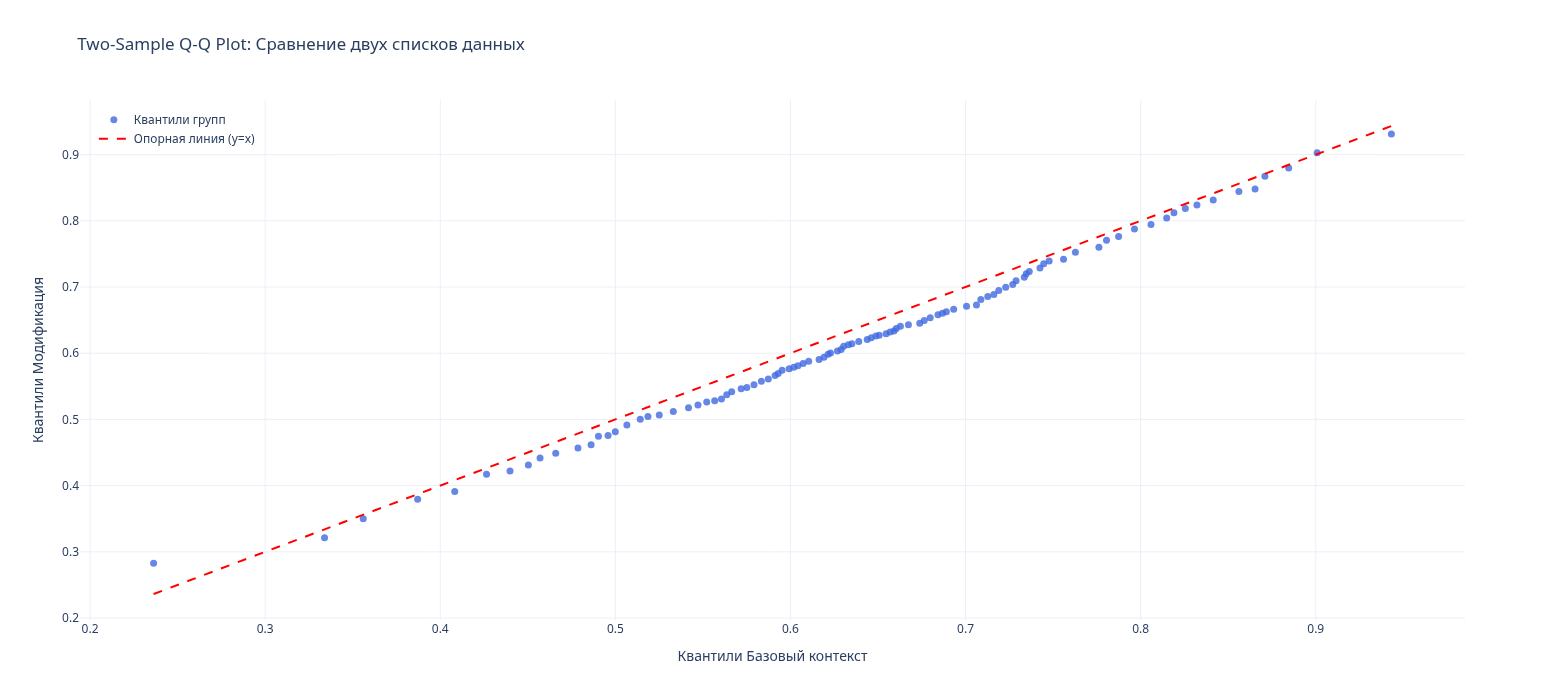

In [16]:
fig = qq_func(list1, list2_2)
# Показываем график
fig.show()

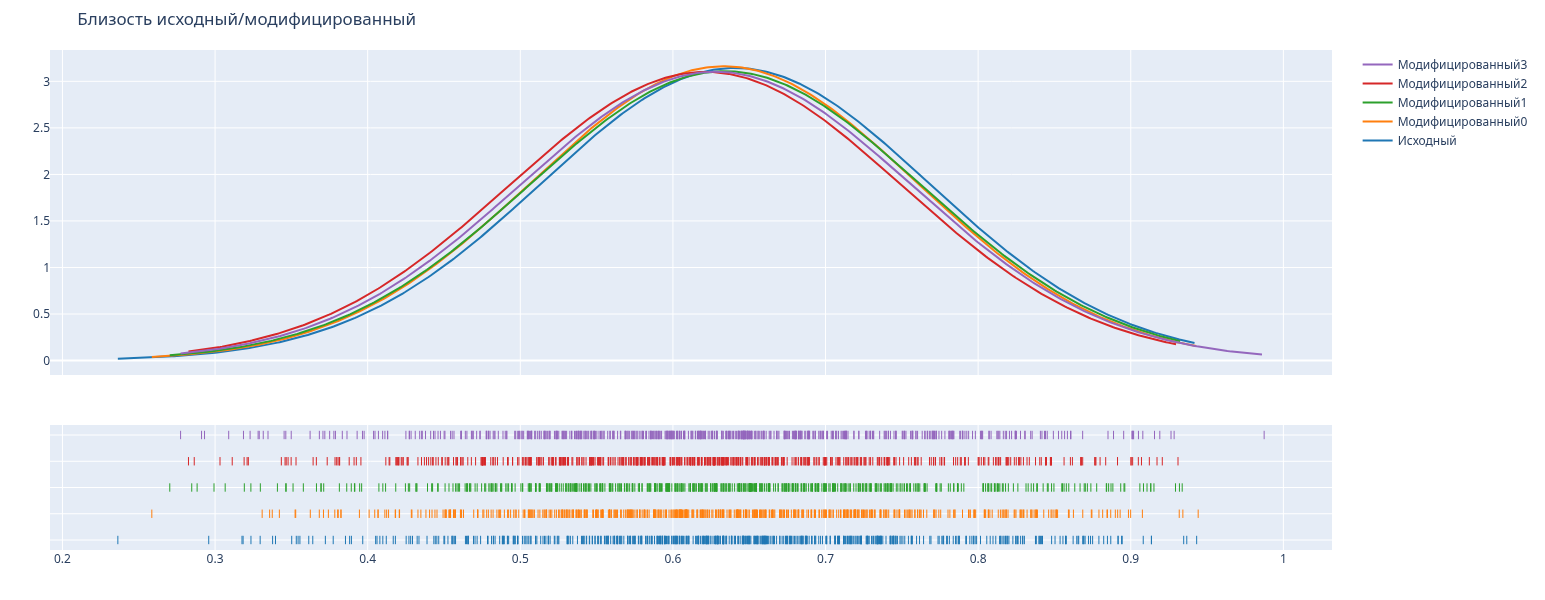

In [17]:
group_labels = ['Исходный', 'Модифицированный0', 'Модифицированный1', 'Модифицированный2', 'Модифицированный3']

# Create distplot with curve_type set to 'normal'
fig = ff.create_distplot(
    [
        base["similarity"],
        perturb_0["similarity"],
        perturb_1["similarity"],
        perturb_2["similarity"],
        perturb_3["similarity"],
    ], group_labels, 
    bin_size=.01,
    curve_type='normal', # override default 'kde'
    show_hist=False,
    rug_text=[
        base.index,
        perturb_0.index,
        perturb_1.index,
        perturb_2.index,
        perturb_3.index,
    ]
)

# Add title
fig.update_layout(title_text='Близость исходный/модифицированный')
# 3. Настраиваем ширину, высоту и другие параметры макета
fig.update_layout(
    width=1200,   # Ширина в пикселях
    height=600,  # Высота в пикселях
    margin=dict(l=50, r=50, t=50, b=50) # Отступы от краев (опционально)
)
fig.show()